### $$\text{\LARGE \textbf{Apprentissage Fédéré sur le jeu de données MNIST}}$$
$$\text{\large \textcolor{blue}{\textbf{Benjamin SWIETEK - MASTER MIGS 2}}}$$

In [12]:
import io
import math
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, transforms
import torch
from collections import Counter
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
from torch.utils.data import Subset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Exécution des calculs sur : {device}")

ds = datasets.MNIST("./data", train=True, download=True, transform=transforms.ToTensor())

Exécution des calculs sur : cuda


### $\LARGE \textbf{Présentation du jeu de données MNIST}$

### Le jeu de données MNIST rassemble 70 000 images de chiffres manuscrits avec 60 000 pour l'entraînement et 10 000 pour les tests, normalisées et centrées dans des images 28×28 pixels. Sa structure est parfaite pour expérimenter l'apprentissage fédéré. La diversité des écritures manuscrites est illustrée dans la visualisation suivante :

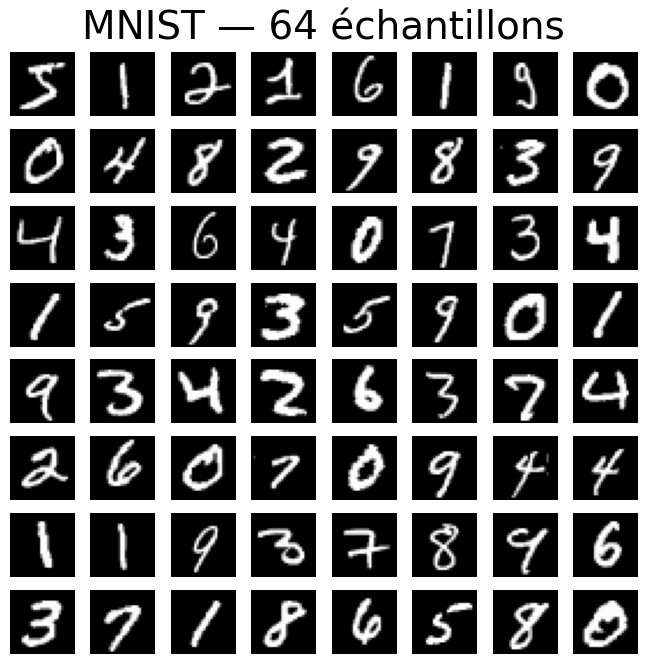

In [3]:
mnist_train = datasets.MNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())

fig, ax = plt.subplots(nrows=8,ncols=8,figsize=(7,7)) 
fig.subplots_adjust(left=0.05, right=0.95, bottom=0.06, top=0.92)  # centre + marges
fig.suptitle("MNIST — 64 échantillons", fontsize=28)         
c=-1
for l in range(64) :
    if ((l % 8) == 0) : 
        c=c+1
    img, label = mnist_train[l]
    ax[l%8,c].imshow(img[0],cmap="gray")
    ax[l%8,c].axis("off")
    ax[l%8,c].set_aspect("equal")



### $\LARGE \textbf{Présentation de la régression logistique multinomial}$

<div align="justify">

La régression logistique multinomial sera le modèle utilisé pour la classification des chiffres manuscrits MNIST.

</div>

---

#### $\large \textbf{Formalisation du problème}$

**Données d'apprentissage** :
$$
\{(x_i,y_i)\}_{i=1}^n,\quad x_i\in\mathbb{R}^d,\quad y_i\in\{1,\dots,K\}
$$

**Représentation one-hot** :
$$
Y \in \{0,1\}^{n\times K}
$$

**Paramètres du modèle** :
$$
W = [\beta_1, \dots, \beta_K] \in \mathbb{R}^{d\times K}, \quad b \in \mathbb{R}^K,\quad b\in\mathbb{R}^K \text{ (biais)}
$$

---

#### $\large \textbf{Architecture du modèle}$

**Calcul des logits** :
$$
z_{ij} = x_i^\top \beta_j + b_j
$$

**Fonction softmax** :
$$
p_{ij} = \frac{e^{z_{ij}}}{\sum_{k=1}^K e^{z_{ik}}}, \quad \sum_{j=1}^K p_{ij} = 1
$$

---

#### $\large \textbf{Fonction de coût et optimisation}$

**Log-vraisemblance** :
$$
\ell(W,b) = \sum_{i=1}^n\sum_{j=1}^K y_{ij}\,z_{ij} - \sum_{i=1}^n\log\!\Big(\sum_{k=1}^K e^{z_{ik}}\Big)
$$

**Gradients par classe** :
$$
\nabla_{\beta_j}\ell = \sum_{i=1}^n (y_{ij}-p_{ij})\,x_i, \quad
\frac{\partial \ell}{\partial b_j} = \sum_{i=1}^n (y_{ij}-p_{ij})
$$

---

#### $\large \textbf{Optimisations techniques}$

**Formulation standard** (sans absorption) :
$$
\nabla_W \ell = X^\top (Y - P),\quad \nabla_b \ell = \mathbf{1}^\top (Y - P)
$$

**Régularisation $L_2$** (uniquement sur $W$) :
$$
J(W,b) = -\ell(W,b) + \frac{\lambda}{2}\|W\|_F^2
$$

**Mise à jour des paramètres** :
$$
W \leftarrow W + \eta\left[X^\top (Y - P) - \lambda W\right],\quad
b \leftarrow b + \eta\,\mathbf{1}^\top (Y - P)
$$

---

In [4]:

ds = datasets.MNIST("./data",train=True,download=True,transform=transforms.ToTensor())

def initialisation(ind_client, clients):
    subset = clients[ind_client]
    n = len(subset)
    K = 10
    
    X = torch.stack([subset[i][0].view(-1) for i in range(n)]).to(device)
    y = torch.tensor([subset[i][1] for i in range(n)], dtype=torch.int64, device=device)
    Y = torch.nn.functional.one_hot(y, num_classes=K).to(torch.float32)
    ones = torch.ones((n, 1), dtype=torch.float32, device=device)
    X_aug = torch.hstack([X, ones])
    
    return X_aug, Y, n


def softmax(Z):
    Zs = Z-Z.max(axis=1,keepdims=True)
    return np.exp(Zs)/np.exp(Zs).sum(axis=1,keepdims=True)

def epoque_locale_vectorisee(X_sel, Y_sel, epochs_local, lambda_l2, lr, W_global, batch_size):
    """
    Entraîne TOUS les clients sélectionnés en même temps.
    X_sel a pour dimension : (Nb_clients, Nb_images, 785)
    """
    m, n_c, _ = X_sel.shape
    
    # On duplique la matrice W_global pour chaque client -> (m, 785, 10)
    W = W_global.unsqueeze(0).repeat(m, 1, 1).clone()
    
    reg_mask = torch.ones_like(W_global)
    reg_mask[-1, :] = 0.0
    reg_mask = reg_mask.unsqueeze(0) # Pour correspondre aux dimensions
    
    if batch_size == float('inf') or batch_size == np.inf:
        batch_size = n_c
        
    # Création d'un index de base pour sélectionner les clients en parallèle
    batch_idx = torch.arange(m, device=device).unsqueeze(1)
        
    for _ in range(epochs_local):
        # 1. Mélange des images (indépendant pour chaque client !)
        idx = torch.rand(m, n_c, device=device).argsort(dim=1)
        Xs = X_sel[batch_idx, idx]
        Ys = Y_sel[batch_idx, idx]
        
        # 2. Boucle sur les mini-batchs
        for start in range(0, n_c, batch_size):
            xb = Xs[:, start:start+batch_size, :] # Dimension : (m, batch_size, 785)
            yb = Ys[:, start:start+batch_size, :] # Dimension : (m, batch_size, 10)
            b_size = xb.shape[1]
            
            # Multiplication matricielle en lot (Batch Matrix Multiplication)
            Z = torch.bmm(xb, W) 
            P = torch.softmax(Z, dim=2)
            
            # Calcul du gradient en lot
            grad = torch.bmm(xb.transpose(1, 2), (yb - P)) / b_size - lambda_l2 * (W * reg_mask)
            W += lr * grad
            
    return W
 
def data_test():
    test_ds = datasets.MNIST("./data", train=False, download=True, transform=transforms.ToTensor())
    n = len(test_ds)
    X_te = torch.stack([test_ds[i][0].view(-1) for i in range(n)]).to(device)
    y_te = torch.tensor([test_ds[i][1] for i in range(n)], dtype=torch.int64, device=device)
    ones = torch.ones((n, 1), dtype=torch.float32, device=device)
    X_te_aug = torch.hstack([X_te, ones])
    return X_te_aug, y_te

def prop_pred(X_aug, y_true, W):
    Z = X_aug @ W
    y_pred = torch.argmax(Z, dim=1)
    return (y_pred == y_true).to(torch.float32).mean().item()


## $\large \textbf{Algorithme Federated Averaging}$

---

### $\textbf{Hyperparamètres}$

| Nom              | Description                                               |
|------------------|-----------------------------------------------------------|
| $R$              | Nombre de rounds de communication globaux                 |
| $E$              | Nombre d’époques locales effectuées par client            |
| $B$              | Taille de mini-batch local
| $\eta$            | Taux d’apprentissage local                                |
| $C$  | Fraction de clients sélectionnés à chaque round           |

---

### $\textbf{Protocole étape par étape}$

### 1. Initialisation (serveur)

$\hspace{10cm}$ $\blacktriangleright$ Le serveur initialise les poids globaux $w^{(0)}$.

$\hspace{10cm}$ $\blacktriangleright$ Il fixe les hyperparamètres : $(R, E, B, \nu, \mathrm{frac})$.

### 2. Sélection des clients (round $t = 0, \dots, R-1$)

$\hspace{10cm}$ $\blacktriangleright$ Le serveur échantillonne un sous-ensemble de clients $S_t \subset \{1, ..., K\}$ tel que  $|S_t| = \max\big(1, \lfloor C \cdot K \rfloor\big)$.

$\hspace{10cm}$ $\blacktriangleright$ Il diffuse $w^{(t)}$ à tous les clients $k \in S_t$.

### 3. Entraînement local (client $k$)

$\hspace{10cm}$ $\blacktriangleright$ Chaque client effectue $E$ époques de mini-batch à partir de $w^{(t)}$.

$\hspace{10cm}$ $\blacktriangleright$ Pour chaque mini-batch $\mathcal{B}$ de taille $m = \min(B, |\text{reste}|)$ : $$ g_k(w;\mathcal{B}) = \frac{1}{m} \sum_{(x,y)\in \mathcal{B}} \nabla_w \ell(w; x, y), \quad w \leftarrow w - \eta \cdot g_k(w;\mathcal{B}) $$

$\hspace{10cm}$ $\blacktriangleright$ Si $B = \infty$, alors $m = n_k$ càd une seule mise à jour par époque.

$\hspace{10cm}$ $\blacktriangleright$ À la fin, le client renvoie $w_k^{(t+1)}$ au serveur.

### 4. Agrégation (serveur)
$\hspace{10cm}$ $\blacktriangleright$ Le serveur effectue une moyenne pondérée des modèles locaux : $$ w^{(t+1)} = \sum_{k \in S_t} p_k \cdot w_k^{(t+1)},\qquad p_k = \frac{n_k}{\sum_{u \in S_t} n_u} $$

$\hspace{10cm}$ $\blacktriangleright$ Le modèle global $w^{(t+1)}$ est ensuite redistribué pour le round suivant.

---


In [20]:
def FedAvg(clients, n_rounds,epochs_local,lambda_l2=1e-4,lr=3e-3,lr_decay=0.0,batch_size=128,frac=0.3):
    d = 28*28
    K = 10
    acc_test = []
    X_test, y_test = data_test()
    W_global = (0.01 * torch.randn(d + 1, K, dtype=torch.float32, device=device))
    cached = [initialisation(j, clients) for j in range(len(clients))]
    X_all = torch.stack([c[0] for c in cached]) 
    Y_all = torch.stack([c[1] for c in cached]) 
    m = max(1, int(frac * len(clients)))

    for r in range(n_rounds):
        current_lr = lr / (1.0 + lr_decay * r)
        # Sélection aléatoire des clients
        sel = np.random.choice(len(clients),size=m,replace=False)
        X_sel = X_all[sel]
        Y_sel = Y_all[sel]
        W_locaux = epoque_locale_vectorisee(X_sel,Y_sel,epochs_local,lambda_l2,current_lr,W_global,batch_size)
        # Agrégation 
        W_global = W_locaux.mean(dim=0)
        acc = prop_pred(X_test, y_test,W_global)
        acc_test.append(acc)
        #if acc >= 0.8:
        #    print(f"Objectif de {0.8*100}% atteint au round {r+1} ! (Arrêt anticipé)")
        #    break
    return W_global, acc_test


In [6]:
def nbr_rounds_lim(acc_curve, target=0.90):
    for r, v in enumerate(acc_curve):
        if v >= target: return r + 1
    return None


def fct_u(E, B, n_bar):
    if B == float('inf') or B == np.inf: return int(E)
    return int(E * (n_bar / B))


def tab_graph(clients, configs, target=0.99, n_rounds=1000, lr=3e-3, lr_decay=0.0, lambda_l2=1e-4, frac=0.1):
    N = sum(len(cl.indices) for cl in clients)
    K = len(clients)
    n_bar = N / K
    res, curves = [], []
    for cfg in configs:
        E, B = cfg['E'], cfg['B']
        Wg, acc_curve = FedAvg(clients, n_rounds=n_rounds, epochs_local=E, lambda_l2=lambda_l2, lr=lr, lr_decay=lr_decay, batch_size=B, frac=frac)
        rtt = nbr_rounds_lim(acc_curve, target=target)
        res.append(dict(E=E, B=B, u=fct_u(E, B, n_bar), rounds=rtt, last_acc=acc_curve[-1]))
        curves.append(acc_curve)
    return pd.DataFrame(res), curves


def data_iid(ds, n_clients=100, seed=0):
    y = ds.targets.numpy() 
    skf = StratifiedKFold(n_splits=n_clients, shuffle=True, random_state=seed)
    return [Subset(ds, idx) for _, idx in skf.split(np.zeros_like(y), y)]


def data_noniid(ds, n_clients=100, shards_per_client=2, seed=0):
    y = ds.targets.numpy()
    order = np.argsort(y)
    n_shards = n_clients * shards_per_client
    shard_size = len(order) // n_shards
    shards = [order[i*shard_size:(i+1)*shard_size] for i in range(n_shards)]
    rng = np.random.default_rng(seed)
    rng.shuffle(shards)
    return [Subset(ds, np.concatenate(shards[c*shards_per_client:(c+1)*shards_per_client])) for c in range(n_clients)]



In [14]:
#Paramètres
# Paramètres
configs = [
    {'E':1,'B':np.inf},
    {'E':5,'B':np.inf},
    {'E':1,'B':50},
    {'E':20,'B':np.inf},
    {'E':1,'B':10},
    {'E':5,'B':50},
    {'E':20,'B':50},
    {'E':5,'B':10},
    {'E':20,'B':10},
]

clients_iid = data_iid(ds, n_clients=100)
clients_noniid = data_noniid(ds, n_clients=100, shards_per_client=2, seed=0)
DECAY = 0.01

df_iid, curves_iid = tab_graph(clients_iid, configs, target=0.8, n_rounds=500, lr=3e-3, lr_decay=DECAY, lambda_l2=1e-4, frac=0.3)
df_noniid, curves_noniid = tab_graph(clients_noniid, configs, target=0.8, n_rounds=500, lr=3e-3, lr_decay=DECAY, lambda_l2=1e-4, frac=0.3)
tbl = (df_iid[['E','B','u','rounds']].rename(columns={'rounds':'IID'})).merge(df_noniid[['E','B','u','rounds']].rename(columns={'rounds':'NON-IID'}), on=['E','B','u'], how='inner')

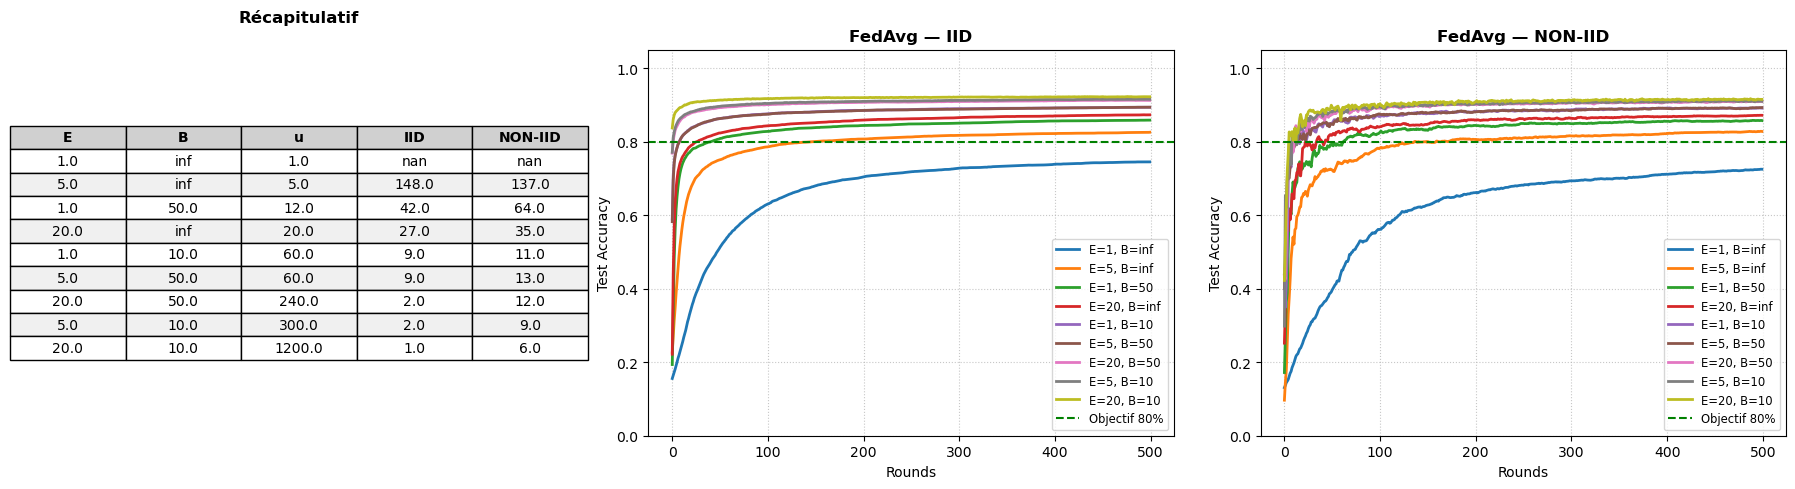

In [15]:
# --- AFFICHAGE DES RÉSULTATS ---

def fct_tableau(title, df, ax):
    ax.axis('off')
    ax.set_title(title, fontweight='bold', pad=20)
    table = ax.table(cellText=df.values, colLabels=df.columns, cellLoc='center', loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.1, 1.4)
    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_text_props(weight='bold')
            cell.set_facecolor('#d0d0d0')
        elif row > 0:
            cell.set_facecolor('#f0f0f0' if row % 2 == 0 else 'white')

def plot_curve(ax, curves, title):
    for acc, label in zip(curves, [f"E={c['E']}, B={c['B']}" for c in configs]):
        # ⚡ ATTENTION ICI : On affiche tout "acc" et on enlève le [:500] !
        ax.plot(acc, label=label, linewidth=2)
        
    ax.axhline(0.8, color='green', linestyle='--', linewidth=1.5, label='Objectif 80%')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel("Rounds")
    ax.set_ylabel("Test Accuracy")
    ax.set_ylim(0, 1.05) # Force l'axe Y entre 0 et 100%
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.legend(fontsize="small", loc="lower right")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Affichage du tableau (axes[0] = le premier tiers à gauche)
fct_tableau("Récapitulatif", tbl, axes[0])

# Affichage des deux graphiques (axes[1] et axes[2])
plot_curve(axes[1], curves_iid, "FedAvg — IID")
plot_curve(axes[2], curves_noniid, "FedAvg — NON-IID")

plt.tight_layout()
plt.show()

L’objectif est d’évaluer le comportement de l’algorithme **FedAvg** en fonction de ses principaux hyperparamètres $\textbf{E}$ et $\textbf{B}$, et le nombre moyen d’itérations locales $\bm{u = \frac{E n}{K B}}$ dans des données **IID**  et **non-IID**. 

On fais varier $\textbf{E}$ et $\textbf{B}$ pour observer leur influence sur le nombre de tours de communication nécessaires pour atteindre une certaine accuracy.
Cette étude suit la méthodologie de McMahan et al. (2017).

L’objectif est d’analyser comment un compromis entre calcul local et communication global peut améliorer l’efficacité de l’apprentissage fédéré.

---
### Interprétation des résultats

**Influence de $\textbf{E}$** :  
  Lorsque le nombre d’époques locales $\textbf{E}$ augmente, le nombre de rounds nécessaires chute considérablement.  
  Chaque client effectue davantage d’apprentissage local avant la synchronisation, ce qui réduit la fréquence des échanges avec le serveur et donc le coût de communication.  

**Influence de $\textbf{B}$** :  
  Diminuer la taille de batch $\textbf{B}$ (donc augmenter $\textbf{u}$) améliore la vitesse de convergence.  
  Les clients effectuent plus de mises à jour locales par round, ce qui accélère l’apprentissage.

**Cas IID vs non-IID** :  
  En **IID** les clients ont des distributions similaires donc la convergence est stable et rapide.  
  En **non-IID**, la convergence est plus lente car les modèles locaux s’éloignent les uns des autres lorsque $\textbf{B}$ est grand.  
  
---

FedAvg fonctionne mieux quand on équilibre le calcul local et la fréquence de communication.  
Augmenter $\textbf{E}$ et réduire $\textbf{B}$ permet de gagner en efficacité.

---
## $\large \textbf{Effet de la fraction de clients sélectionnés C}$

Cette analyse porte sur l’influence de la fraction de clients participant à chaque round. Pour
cette étude le nombre d’époques locales est fixé à E = 5 et deux régimes de calcul distincts
sont comparés, l’un en full-batch et l’autre en mini-batch B = 10. L’objectif est de déterminer
si l’augmentation du nombre de participants accélère la convergence vers une précision de test
cible de 80 %, en fonction de l’hétérogénéité de la distribution des données.

In [9]:
#paramètres
configs= [{'E':5,'B':np.inf}, {'E':5,'B': 10}]
C_list = [0.0,0.1,0.2,0.5,1]
clients_iid = data_iid(ds,n_clients=100)
clients_noniid = data_noniid(ds,n_clients=100,shards_per_client=2,seed=0)

def test_C(clients,C_list,configs):
    dfs = []
    all_curves = [] 
    for C in C_list:
        frac_eff = max(C, 1/len(clients))
        df, current_curves = tab_graph(clients,configs,target=0.8,n_rounds=500,lr=3e-3,lr_decay=DECAY,lambda_l2=1e-4,frac=frac_eff)  
        df["C"] = C
        dfs.append(df)
        all_curves.extend(current_curves)
        
    return pd.concat(dfs,ignore_index=True),all_curves


DECAY = 0.01
df_iid,curves_iid = test_C(clients_iid,C_list,configs)
df_noniid,curves_noniid = test_C(clients_noniid,C_list,configs)

C:\Users\SWIETEK\AppData\Local\Temp\ipykernel_15632\1536756797.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tbl_10[col] = tbl_10[col].apply(lambda v: f"{int(v)}" if v == base else f"{int(v)} ({base/v:.2f}x)")
C:\Users\SWIETEK\AppData\Local\Temp\ipykernel_15632\1536756797.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tbl_inf[col] = tbl_inf[col].apply(lambda v: f"{int(v)}" if v == base else f"{int(v)} ({base/v:.2f}x)")


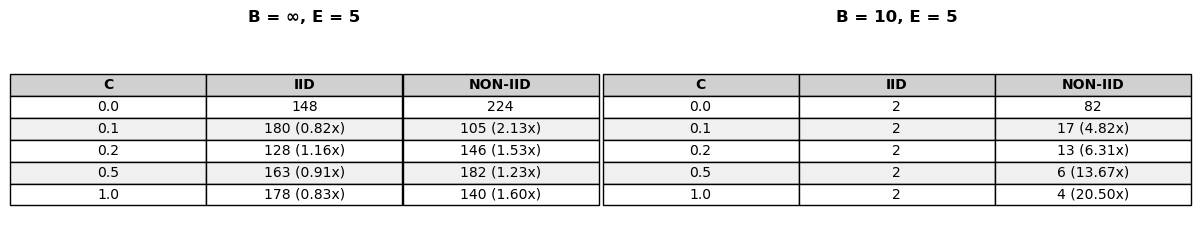

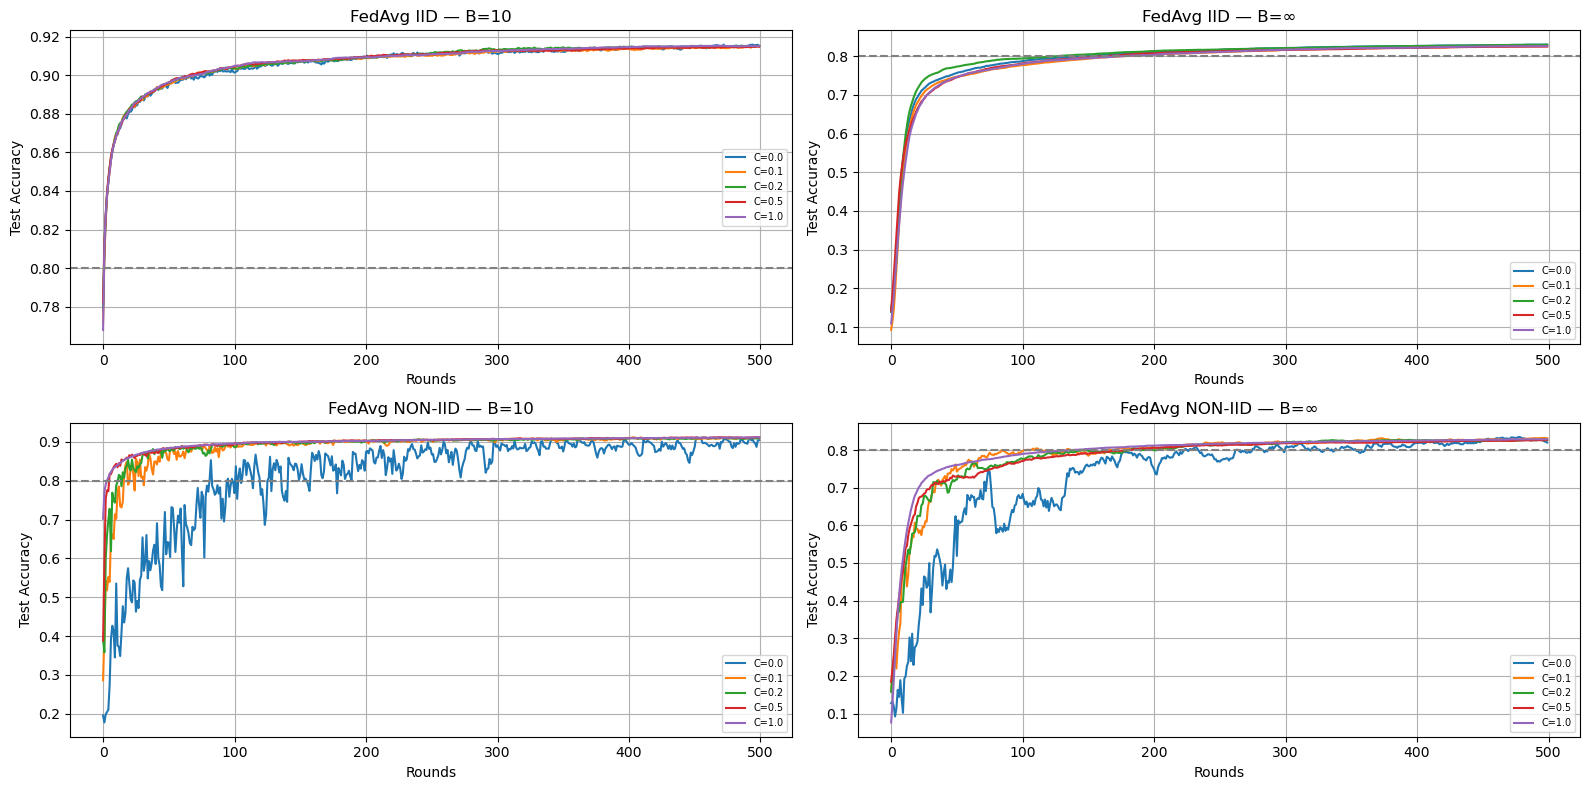

In [11]:

# --- AFFICHAGE DES RÉSULTATS ---

def fct_tableau(title, df, ax):
    ax.axis('off')
    ax.set_title(title, fontweight='bold', pad=20)
    table = ax.table(cellText=df.values, colLabels=df.columns, cellLoc='center', loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.1, 1.4)
    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_text_props(weight='bold')
            cell.set_facecolor('#d0d0d0')
        elif row > 0:
            cell.set_facecolor('#f0f0f0' if row % 2 == 0 else 'white')

def plot_curves(ax,curves,cfgs,B_target,title):
    for acc,cfg in zip(curves,cfgs.itertuples(index=False)):
        if cfg.B == B_target:
            label = f"C={cfg.C}"
            ax.plot(acc, label=label)
    ax.axhline(0.8,color='gray',linestyle='--')
    ax.set_title(f"{title}")
    ax.set_xlabel("Rounds")
    ax.set_ylabel("Test Accuracy")
    ax.grid(True)
    ax.legend(fontsize='x-small')


# Les tableaux
tbl = (df_iid[['E','B','C','rounds']].rename(columns={'rounds':'IID'})).merge(df_noniid[['E','B','C','rounds']].rename(columns={'rounds':'NON-IID'}),on=['E','B','C'],how='inner')
tbl['B'] = tbl['B'].apply(lambda b: '∞' if b == np.inf else str(int(b)))
tbl_10 = tbl[tbl['B'] == "10"]
tbl_inf = tbl[tbl['B'] == '∞']

for col in ['IID', 'NON-IID']:
    base = tbl_10[col].iloc[0]
    tbl_10[col] = tbl_10[col].apply(lambda v: f"{int(v)}" if v == base else f"{int(v)} ({base/v:.2f}x)")
    base = tbl_inf[col].iloc[0]
    tbl_inf[col] = tbl_inf[col].apply(lambda v: f"{int(v)}" if v == base else f"{int(v)} ({base/v:.2f}x)")

fig_tbl, ax_tbl = plt.subplots(1,2,figsize=(12,2.5))
fct_tableau(f"B = ∞, E = {tbl_inf['E'].iloc[0]}",tbl_inf[['C','IID','NON-IID']],ax_tbl[0])
fct_tableau(f"B = 10, E = {tbl_10['E'].iloc[0]}",tbl_10[['C','IID','NON-IID']],ax_tbl[1])
plt.tight_layout()
plt.show()




# Les graphes
params = [
    (curves_iid,df_iid,10,"FedAvg IID — B=10"),
    (curves_iid,df_iid,np.inf,"FedAvg IID — B=∞"),
    (curves_noniid,df_noniid,10,"FedAvg NON-IID — B=10"),
    (curves_noniid,df_noniid,np.inf,"FedAvg NON-IID — B=∞"),
]
fig, axes = plt.subplots(2,2,figsize=(16,8))
for ax, (curves,cfgs,B_val,title) in zip(axes.flat,params):
    plot_curves(ax,curves,cfgs,B_val,title)
plt.tight_layout()
plt.show()

Dans cette d’expérience, on garde fixes le nombre d’époques locales  $\textbf{E} = 5$ et deux tailles de batch :  $\textbf{B} = \infty$ et  $\textbf{B} = 10$ et on fait varier la fraction de clients $ \textbf{C} = \in \{0.0, 0.1, 0.2, 0.5, 1.0\}$.

L’objectif est de voir si impliquer plus de clients par round accélère réellement FedAvg, et si cet effet est le même en **IID** et en **non-IID**.

---

#### Cas $\textbf{B} = \infty, \textbf{E} = 5$

Pour les données **IID** le nombre de rounds est quasiment constant quel que soit $\textbf{C}$.

Pour les données **Non-IID** on voit un petit gain quand $\textbf{C}$ augmente mais le gain reste modéré.

Si les updates se font avec un gros batch, augmenter $\textbf{C}$ n’apporte pas grand-chose.


#### Cas $\textbf{B} = 10, \textbf{E} = 5$

Pour les données **IID** quelle que soit la valeur de $\textbf{C}$, on atteint la cible en 2 rounds. 

Pour les données **Non-IID** lorsque les updates locales se font avec un petit batch $\textbf{B}$, alors moyenner plus de clients dans le même round corrige le biais local.  

Donc avec des clients hétérogènes, la variance est entre les clients, donc la meilleure façon de la réduire, c’est de moyenner plus de clients.

En conclusion l’effet de $\textbf{C}$ apparaît surtout quand les données sont non-IID et que le batch est petit. 

---

Cela montre que la fraction de clients sélectionnés par round $\textbf{C}$ n’a qu’un impact limité lorsque les mises à jour locales ont un grand batch, mais devient un levier important dès que les données sont hétérogènes et que les clients utilisent de petits batch.

---
## $\large \textbf{Impact du taux d’apprentissage η}$

Cette étude évalue la sensibilité de l’algorithme FedAvg au taux d’apprentissage η. 

Les autres hyperparamètres sont maintenus fixes (E = 5, B = 10, C = 0, 1) afin d’isoler l’effet du pas de
gradient.

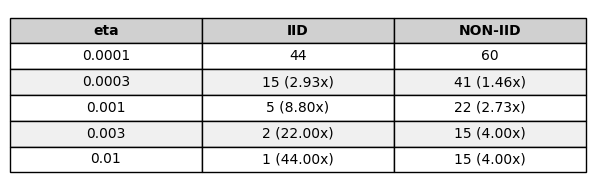

In [ ]:
#Paramètres
eta_list = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2]
config_eta_test = {'E': 5, 'B': 10}
C_eta = 0.1

def test_eta(clients,eta_list,config,C=0.1):
    all_dfs = []
    all_curves = []
    for eta in eta_list:
        df, curves = tab_graph(clients,[config],target=0.8,n_rounds=1200,lr=eta,lambda_l2=1e-4,frac=C)
        df["eta"] = eta
        all_dfs.append(df)
        all_curves.append(curves[0])
    return pd.concat(all_dfs,ignore_index=True),all_curves

df_eta_iid, curves_eta_iid = test_eta(clients_iid,eta_list,config_eta_test,C=C_eta)
df_eta_noniid, curves_eta_noniid = test_eta(clients_noniid,eta_list,config_eta_test,C=C_eta)
tbl_eta = df_eta_iid[['eta','rounds']].rename(columns={'rounds':'IID'}).merge(df_eta_noniid[['eta','rounds']].rename(columns={'rounds':'NON-IID'}), on='eta')

for col in ['IID','NON-IID']:
    base = tbl_eta[col].iloc[0]
    tbl_eta[col] = tbl_eta[col].apply(lambda v: f"{int(v)}" if v == base else f"{int(v)} ({base/v:.2f}x)")

#Tableau
fig, ax = plt.subplots(figsize=(6, 2))
fct_tableau("",tbl_eta,ax)
plt.tight_layout()
plt.show()


Dans cette expérience, on évalue l’impact du taux d’apprentissage $\bm{\eta}$ sur la convergence de FedAvg.  
Les autres hyperparamètres sont fixés à $\textbf{E}$ = 5, $\textbf{B}$ = 10 et $\textbf{C}$ = 0.1.  
On teste plusieurs valeurs de $\bm{\eta} \in \{10^{-4}, 3\!\times\!10^{-4}, 10^{-3}, 3\!\times\!10^{-3}, 10^{-2}\}$.

---

### Interprétation des résultats

**Pour les données IID :**  
  La convergence s’accélère fortement lorsque $\bm{\eta}$ augmente, passant de 44 rounds à seulement 1 round.  
  Les mises à jour locales deviennent plus efficaces et la moyenne globale converge presque instantanément.

**Pour les données non‐IID :**  
  La tendance est similaire mais plus modérée la vitesse de convergence est environ multipliée par 4, puis se stabilise au-delà d’un certain seuil.  
  Les gradients locaux étant plus hétérogènes, une trop grande valeur de $\bm{\eta}$ peut amplifier les divergences entre clients.

---

En **IID**, augmenter $\bm{\eta}$ améliore nettement la vitesse de convergence jusqu’à un certain seuil.  
En **non‐IID** la stabilité devient le facteur limitant, un $\bm{\eta}$ trop grand n’apporte plus de gain et peut même dégrader la précision finale.  
Le choix du taux d’apprentissage doit donc trouver un équilibre entre rapidité et stabilité, en fonction du niveau d’hétérogénéité des données.

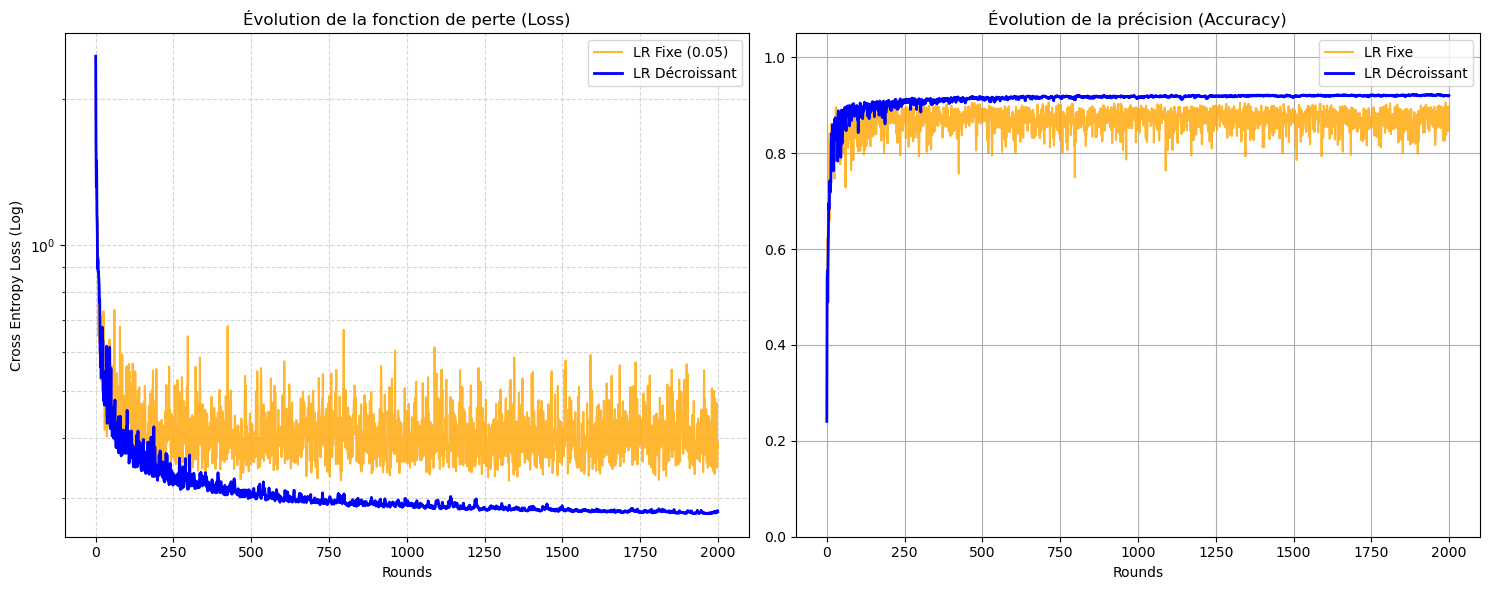

In [18]:

def prop_pred_loss(X_aug,y_true, W):
    Z = X_aug @ W
    y_pred = torch.argmax(Z, dim=1)
    acc = (y_pred == y_true).to(torch.float32).mean().item()
    P = torch.softmax(Z,dim=1)
    Y_oh = torch.nn.functional.one_hot(y_true,num_classes=10).to(torch.float32)
    epsilon = 1e-9
    loss = -torch.sum(Y_oh * torch.log(P + epsilon)) / X_aug.shape[0]
    
    return loss.item(), acc

def FedAvg_lr(clients,n_rounds,epochs_local,lambda_l2=1e-4,lr=3e-3,lr_decay=0.0,batch_size=128,frac=0.3):
    d = 28 * 28
    K = 10
    acc_test = []
    loss_test = [] 
    X_test, y_test = data_test()
    W_global = (0.01 * torch.randn(d+1,K,dtype=torch.float32,device=device))
    cached = [initialisation(j, clients) for j in range(len(clients))]
    X_all = torch.stack([c[0] for c in cached]) 
    Y_all = torch.stack([c[1] for c in cached]) 
    m = max(1, int(frac*len(clients)))

    for r in range(n_rounds):
        current_lr = lr/(1.0+lr_decay*r)       
        sel = np.random.choice(len(clients),size=m,replace=False)
        X_sel = X_all[sel]
        Y_sel = Y_all[sel]       
        W_locaux = epoque_locale_vectorisee(X_sel,Y_sel,epochs_local,lambda_l2,current_lr,W_global,batch_size)
        W_global = W_locaux.mean(dim=0)    
        loss, acc = prop_pred_loss(X_test,y_test,W_global)
        acc_test.append(acc)
        loss_test.append(loss)

    return loss_test, acc_test 



# LANCEMENT LR FIXE vs LR DÉCROISSANT
clients_noniid = data_noniid(ds, n_clients=100, shards_per_client=2, seed=0)
ROUNDS = 2000
EPOCHS = 5
BATCH = 10
FRAC = 0.1
LR_INITIAL = 0.05

loss_fixe, acc_fixe = FedAvg_lr(clients_noniid,n_rounds=ROUNDS,epochs_local=EPOCHS,lambda_l2=1e-4,lr=LR_INITIAL,lr_decay=0.0,batch_size=BATCH,frac=FRAC)
loss_decay, acc_decay = FedAvg_lr(clients_noniid,n_rounds=ROUNDS,epochs_local=EPOCHS,lambda_l2=1e-4,lr=LR_INITIAL,lr_decay=0.05,batch_size=BATCH,frac=FRAC)

# AFFICHAGE 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Loss
ax1.plot(loss_fixe, label='LR Fixe (0.05)',color='orange',alpha=0.8)
ax1.plot(loss_decay, label='LR Décroissant',color='blue',linewidth=2)
ax1.set_yscale('log') 
ax1.set_title("Évolution de la fonction de perte (Loss)")
ax1.set_xlabel("Rounds")
ax1.set_ylabel("Cross Entropy Loss (Log)")
ax1.grid(True, which="both", linestyle='--',alpha=0.5)
ax1.legend()

# Accuracy
ax2.plot(acc_fixe,label='LR Fixe',color='orange',alpha=0.8)
ax2.plot(acc_decay,label='LR Décroissant', color='blue',linewidth=2)
ax2.set_title("Évolution de la précision (Accuracy)")
ax2.set_xlabel("Rounds")
ax2.set_ylim(0,1.05)
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

---
## $\large \textbf{Fuite et reconstruction des données via les gradients}$

L’apprentissage fédéré est conçu pour préserver la confidentialité des données mais son intégrité
repose sur l’hypothèse fondamentale que le partage des mises à jour de modèle ne dévoile pas la
nature des données. Cette section montre que cette hypothèse est mise en défaut dans le cas de
la régression logistique multinomiale particulièrement lorsque le volume de données d’un client
est petit.

Victime : Client 0, Image index 0
Classe réelle de l'image : 5


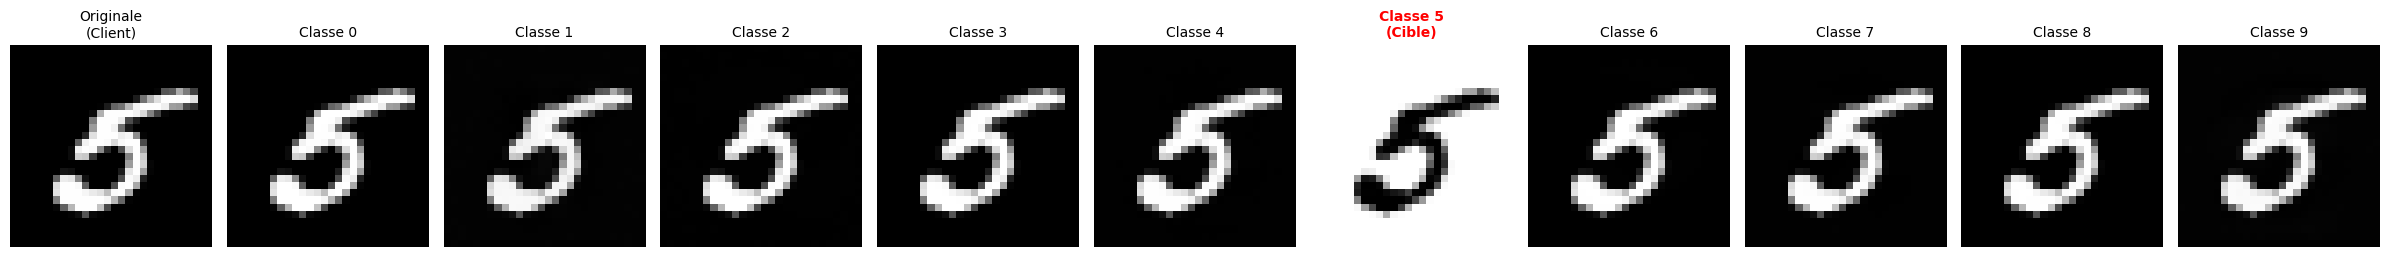

In [ ]:
def demo_attaque_inversion_gradient(clients,W_global,lambda_l2=1e-4,lr=0.01):
    ind_client_victime = 0
    X_aug,Y,n= initialisation(ind_client_victime,clients)
    idx_image = 0
    X_victime = X_aug[idx_image:idx_image+1] 
    Y_victime = Y[idx_image:idx_image+1]     
    label_reelle = torch.argmax(Y_victime).item() 
    
    print(f"Victime : Client {ind_client_victime}, Image index {idx_image}")
    print(f"Classe réelle de l'image : {label_reelle}")
    X_sel = X_victime.unsqueeze(0)
    Y_sel = Y_victime.unsqueeze(0) 
    
    W_new_batch = epoque_locale_vectorisee(X_sel,Y_sel,epochs_local=1,lambda_l2=lambda_l2,lr=lr,W_global=W_global,batch_size=1) 
    W_new = W_new_batch.squeeze(0) 
    gradient_reconstruit = (W_global - W_new) / lr 
    
    #Visualisation
    plt.figure(figsize=(24,3)) 
    plt.subplot(1,11,1) 
    plt.title("Originale\n(Client)", fontsize=10)
    img_originale = X_victime[0,:-1].cpu().numpy().reshape(28, 28)
    plt.imshow(img_originale, cmap='gray')
    plt.axis('off')

    for k in range(10):
        plt.subplot(1,11,k+2) 
        
        # Rapatriement du gradient de la classe k sur le CPU
        grad_col = gradient_reconstruit[:-1,k].cpu().numpy()
        img_reconstruite = grad_col.reshape(28, 28)
        plt.imshow(img_reconstruite,cmap='gray') 
        titre = f"Classe {k}"
        if k == label_reelle:
            plt.title(titre + "\n(Cible)",color='red',fontweight='bold',fontsize=10)
            ax = plt.gca()
            for spine in ax.spines.values():
                spine.set_edgecolor('red')
                spine.set_linewidth(2)
        else:
            plt.title(titre, fontsize=10)
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()


# Lancement
ds = datasets.MNIST("./data",train=True,download=True,transform=transforms.ToTensor())
clients = data_noniid(ds, n_clients=100) 
W_entraine, acc_curve = FedAvg(clients,n_rounds=100,epochs_local=10,lr=0.01)
demo_attaque_inversion_gradient(clients,W_entraine)

---
## $\large \textbf{Étude de la persistance de l’attaque sur des lots de données}$

La reconstruction exacte présentée précédemment repose sur l’unicité de la donnée traitée par
le client. Cette section analyse l’évolution de cette vulnérabilité lorsque le client possède plusieurs images, l’agrégation locale des gradients modifiant la nature de l’information transmise
au serveur.


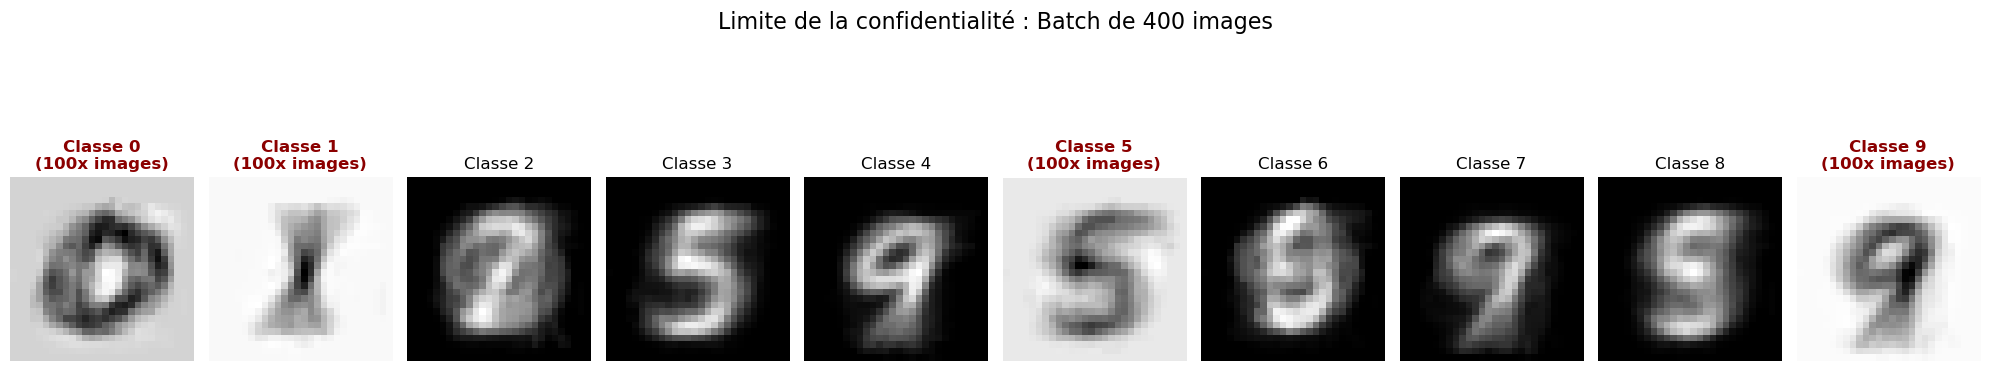

In [23]:
def demo_superposition_limite(clients, W_global, lr=0.01):
    classes_cibles = [0, 1, 5, 9]
    n_images_par_classe = 100 
    dict_X = {c: [] for c in classes_cibles}
    dict_Y = {c: [] for c in classes_cibles} 
    for id_c in range(len(clients)):
        X_aug,Y,_ = initialisation(id_c,clients)
        labels = torch.argmax(Y,dim=1) 
        for c in classes_cibles:
            if len(dict_X[c]) < n_images_par_classe:
                idx = torch.where(labels == c)[0]
                for i in idx:
                    if len(dict_X[c]) < n_images_par_classe:
                        dict_X[c].append(X_aug[i])
                        dict_Y[c].append(Y[i])               
        if all(len(dict_X[c]) == n_images_par_classe for c in classes_cibles):
            break

    X_list = dict_X[0] + dict_X[1] + dict_X[5] + dict_X[9]
    Y_list = dict_Y[0] + dict_Y[1] + dict_Y[5] + dict_Y[9]
    X_batch = torch.stack(X_list) 
    Y_batch = torch.stack(Y_list) 
    n_k = len(X_list)
    X_sel = X_batch.unsqueeze(0) 
    Y_sel = Y_batch.unsqueeze(0) 
    W_new_batch = epoque_locale_vectorisee(X_sel,Y_sel,epochs_local=1,lambda_l2=1e-4,lr=lr,W_global=W_global,batch_size=n_k)
    W_new = W_new_batch.squeeze(0) 
    gradient_intercepte = (W_global-W_new)/lr
    
    # Visualisation
    plt.figure(figsize=(20,5))
    for k in range(10):
        plt.subplot(1,10,k+1)
        grad_col = gradient_intercepte[:-1, k].cpu().numpy()
        img_reconstruite = grad_col.reshape(28,28)
        plt.imshow(img_reconstruite, cmap='gray')
        if k in classes_cibles:
            plt.title(f"Classe {k}\n(100x images)", color='darkred', fontweight='bold')
        else:
            plt.title(f"Classe {k}")
        plt.axis('off')
    plt.suptitle(f"Limite de la confidentialité : Batch de {n_k} images", fontsize=16)
    plt.tight_layout()
    plt.show()

demo_superposition_limite(clients, W_entraine)

---
## $\large \textbf{Inférence d’étiquettes par analyse du gradient}$

Après avoir analysé la vulnérabilité liée à la reconstruction des caractéristiques, il est crucial
d’examiner une autre faille fondamentale qui est la fuite des étiquettes.

 > Batch Size: 1
 > Batch Size: 2
 > Batch Size: 4
 > Batch Size: 8
 > Batch Size: 16
 > Batch Size: 32
 > Batch Size: 64
 > Batch Size: 128
 > Calcul de la Baseline Random Guess...


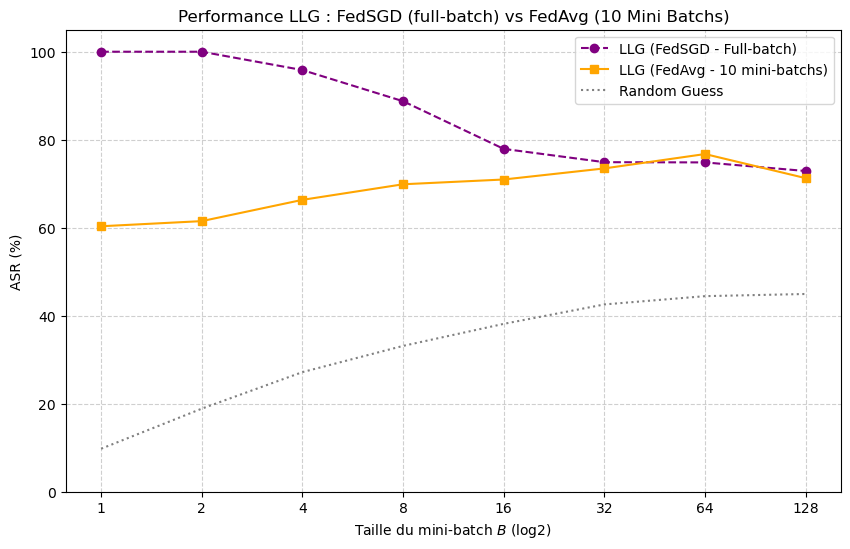

In [26]:

def random_guess_asr(true_labels,n_classes=10,n_sim=1000):
    B = len(true_labels)
    true_counts = Counter(true_labels)
    scores = []
    for _ in range(n_sim):
        preds = np.random.randint(0, n_classes, size=B)
        pred_counts = Counter(preds)
        correct = sum(min(true_counts[k], pred_counts.get(k, 0)) for k in true_counts)
        scores.append(correct / B * 100)
    return np.mean(scores)


# ATTAQUE 

def llg_attack_algo1(gradient_matrix,batch_size,n_classes=10):
    G = np.sum(gradient_matrix,axis=0) 
    G_work = G.copy()
    extracted_labels = []
    # Estimation Impact m
    neg_grads = G_work[G_work<0]
    if len(neg_grads)>0:
        m = (np.sum(neg_grads)/batch_size)*(1+1/n_classes) # Formule empirique de l'article
    else:
        m = -1.0 # Fallback
    # Phase 1 : Signe (Propriété 1)
    initial_negatives = np.where(G_work<0)[0]
    for c in initial_negatives:
        extracted_labels.append(c)
        G_work[c]-=m # On retire l'impact (ce qui augmente la valeur vers 0)
    # Phase 2 : Magnitude (Propriété 2)
    while len(extracted_labels)<batch_size:
        c_min = np.argmin(G_work)
        extracted_labels.append(c_min)
        G_work[c_min] -= m
    return extracted_labels


from collections import Counter

def get_unbalanced_data(ds, total_size, n_classes=10):
    """ Génère un batch déséquilibré (50% A, 25% B, 25% Reste) """
    class_a = np.random.randint(0,n_classes)
    class_b = np.random.randint(0,n_classes)
    while class_b == class_a: class_b=np.random.randint(0,n_classes)
    n_a = int(0.5*total_size)
    n_b = int(0.25*total_size)
    n_rest = total_size-n_a-n_b
    targets = ds.targets.numpy()
    idx_a = np.where(targets==class_a)[0]
    idx_b = np.where(targets==class_b)[0]
    idx_rest = np.where((targets!=class_a) & (targets!=class_b))[0]
    indices = np.concatenate([
        np.random.choice(idx_a,n_a,replace=(n_a>len(idx_a))),
        np.random.choice(idx_b,n_b,replace=(n_b>len(idx_b))),
        np.random.choice(idx_rest,n_rest,replace=(n_rest>len(idx_rest)))
    ])
    
    X_list, y_list = [], []
    for i in indices:
        img, lbl = ds[i]
        X_list.append(img.view(-1).numpy())
        y_list.append(lbl)
        
    X = np.stack(X_list)
    y_vals = np.array(y_list,dtype=np.int64)
    Y = np.zeros((total_size,n_classes),dtype=np.float32)
    Y[np.arange(total_size),y_vals] = 1
    X_aug = np.hstack([X,np.ones((total_size,1),dtype=np.float32)])
    X_aug_gpu = torch.tensor(X_aug, dtype=torch.float32, device=device)
    Y_gpu = torch.tensor(Y, dtype=torch.float32, device=device)
    return X_aug_gpu, Y_gpu, y_vals


def run_comparison_graph():
    ds = datasets.MNIST("./data", train=True, download=True, transform=transforms.ToTensor())
    batch_sizes = [1, 2, 4, 8, 16, 32, 64, 128]
    n_repeats = 30
    lr = 0.1
    d = 28*28
    K = 10
    asr_fedsgd = []
    asr_fedavg = []
    
    for B in batch_sizes:
        print(f" > Batch Size: {B}")
        scores_sgd = []
        scores_avg = []
        for _ in range(n_repeats):
            W_init = (0.01 * torch.randn(d+1, K, dtype=torch.float32, device=device))
            X_gpu, Y_gpu, true_labels = get_unbalanced_data(ds, total_size=B)
            X_sel = X_gpu.unsqueeze(0)
            Y_sel = Y_gpu.unsqueeze(0)
            W_new_batch = epoque_locale_vectorisee(X_sel,Y_sel,1,0,lr,W_init,batch_size=B)
            W_new = W_new_batch.squeeze(0)
            grad_attack_sgd = ((W_init-W_new)/lr).cpu().numpy()
            extracted = llg_attack_algo1(grad_attack_sgd, B)
            c_true = Counter(true_labels)
            c_pred = Counter(extracted)
            correct = sum(min(c_true[k],c_pred[k]) for k in c_true)
            scores_sgd.append(correct/B*100)
            
            # --- FedAvg 10 Batches ---
            total_size_avg = 10 * B
            X_avg_gpu, Y_avg_gpu, true_labels_avg = get_unbalanced_data(ds, total_size=total_size_avg)
            X_sel_avg = X_avg_gpu.unsqueeze(0)
            Y_sel_avg = Y_avg_gpu.unsqueeze(0)
            W_new_batch_avg = epoque_locale_vectorisee(X_sel_avg, Y_sel_avg, 1, 0, lr, W_init, batch_size=B)
            W_new_avg = W_new_batch_avg.squeeze(0)
            grad_attack_avg = ((W_init - W_new_avg) / lr).cpu().numpy()
            extracted_avg = llg_attack_algo1(grad_attack_avg, total_size_avg)
            c_true_avg = Counter(true_labels_avg)
            c_pred_avg = Counter(extracted_avg)
            correct_avg = sum(min(c_true_avg[k], c_pred_avg[k]) for k in c_true_avg)
            scores_avg.append(correct_avg / total_size_avg * 100)
            
        asr_fedsgd.append(np.mean(scores_sgd))
        asr_fedavg.append(np.mean(scores_avg))

    # Calcul Random Guess
    baseline_per_B = []
    print(" > Calcul de la Baseline Random Guess...")
    for B in batch_sizes:
        bs_scores = []
        for _ in range(50): 
            _, _, true_lbl = get_unbalanced_data(ds, total_size=B)
            bs_scores.append(random_guess_asr(true_lbl, n_classes=10, n_sim=200))
        baseline_per_B.append(np.mean(bs_scores))

    # Affichage 
    plt.figure(figsize=(10, 6))
    plt.plot(batch_sizes, asr_fedsgd, 'o--', color='purple', label='LLG (FedSGD - Full-batch)')
    plt.plot(batch_sizes, asr_fedavg, 's-', color='orange', label='LLG (FedAvg - 10 mini-batchs)')
    plt.plot(batch_sizes, baseline_per_B, ':', color='gray', label='Random Guess')
    
    plt.xscale('log', base=2)
    plt.xticks(batch_sizes, labels=batch_sizes)
    plt.xlabel("Taille du mini-batch $B$ (log2)")
    plt.ylabel("ASR (%)")
    plt.title("Performance LLG : FedSGD (full-batch) vs FedAvg (10 Mini Batchs)")
    plt.ylim(0, 105)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.show()

# Lancement
run_comparison_graph()

Calcul de la baseline (Random Guess)...
Baseline établie à 44.7%

--- Simulation : FedSGD (Full Batch) ---
Round   0 | Acc: 8.3% | ASR: 73.8%
Round  10 | Acc: 77.1% | ASR: 74.9%
Round  20 | Acc: 81.8% | ASR: 72.8%
Round  30 | Acc: 83.2% | ASR: 74.6%
Round  40 | Acc: 84.4% | ASR: 74.5%
Round  50 | Acc: 85.3% | ASR: 73.2%
Round  60 | Acc: 85.9% | ASR: 74.1%
Round  70 | Acc: 86.5% | ASR: 71.6%
Round  80 | Acc: 86.8% | ASR: 73.8%
Round  90 | Acc: 86.8% | ASR: 72.8%
Round 100 | Acc: 87.1% | ASR: 74.1%
Round 110 | Acc: 87.4% | ASR: 74.4%
Round 120 | Acc: 87.6% | ASR: 72.9%
Round 130 | Acc: 87.7% | ASR: 73.2%
Round 140 | Acc: 87.9% | ASR: 73.6%
Round 150 | Acc: 88.0% | ASR: 74.6%
Round 160 | Acc: 88.3% | ASR: 73.2%
Round 170 | Acc: 88.4% | ASR: 74.0%
Round 180 | Acc: 88.5% | ASR: 73.8%
Round 190 | Acc: 88.6% | ASR: 72.3%
Round 200 | Acc: 88.7% | ASR: 72.4%

--- Simulation : FedAvg (B=10) ---
Round   0 | Acc: 9.9% | ASR: 69.8%
Round  10 | Acc: 84.8% | ASR: 75.8%
Round  20 | Acc: 87.4% | ASR: 7

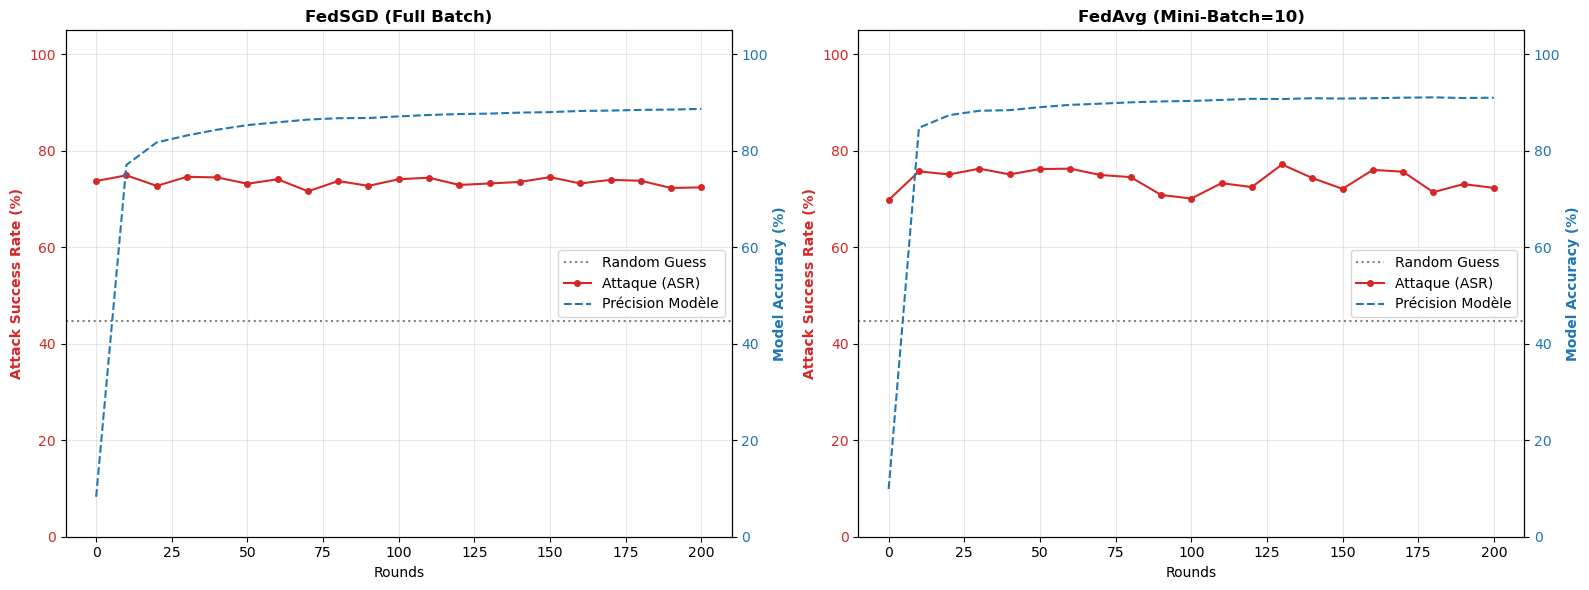

In [ ]:

def get_client_data_unbalanced(ds, indices):
    X_list, y_list = [], []
    for i in indices:
        img, lbl = ds[i]
        X_list.append(img.view(-1).numpy())
        y_list.append(lbl)
    total_size = len(indices)
    X = np.stack(X_list)
    y_vals = np.array(y_list, dtype=np.int64)
    Y = np.zeros((total_size, 10), dtype=np.float32)
    Y[np.arange(total_size), y_vals] = 1
    X_aug = np.hstack([X, np.ones((total_size, 1), dtype=np.float32)])
    return X_aug, Y, y_vals

def setup_clients_unbalanced(ds, n_clients=750):
    client_indices = []
    all_targets = ds.targets.numpy()
    indices_by_label = [np.where(all_targets == i)[0] for i in range(10)]
    for i in range(n_clients):
        c_a, c_b = np.random.choice(10, 2, replace=False)
        n_a, n_b, n_rest = 40, 20, 20 
        idx_a = np.random.choice(indices_by_label[c_a], n_a)
        idx_b = np.random.choice(indices_by_label[c_b], n_b)
        candidates_rest = []
        for l in range(10):
            if l != c_a and l != c_b:
                candidates_rest.extend(indices_by_label[l])
        idx_rest = np.random.choice(candidates_rest, n_rest)
        client_indices.append(np.concatenate([idx_a, idx_b, idx_rest]))
    return client_indices

def run_simulation(mode, clients_indices, n_rounds=200):
    n_clients = len(clients_indices)
    clients_per_round = 50
    lr = 0.1
    samples_per_client = 80
    if mode == 'fedsgd':
        train_batch_size = samples_per_client # Full batch
        label_plot = "FedSGD (Full Batch)"
    else:
        train_batch_size = 10 # Mini-batch typique FedAvg
        label_plot = f"FedAvg (B={train_batch_size})"
    d = 28 * 28
    K = 10
    W_global = (0.01 * torch.randn(d + 1, K, dtype=torch.float32, device=device))
    history_rounds = []
    history_acc = []
    history_asr = []
    print(f"\n--- Simulation : {label_plot} ---")
    
    for r in range(n_rounds + 1):
        # Entraînement
        selected_clients = np.random.choice(n_clients, clients_per_round, replace=False)
        W_sum = torch.zeros_like(W_global)
        for client_id in selected_clients:
            X_c, Y_c, _ = get_client_data_unbalanced(ds, clients_indices[client_id])
            X_c_gpu = torch.tensor(X_c, dtype=torch.float32, device=device).unsqueeze(0)
            Y_c_gpu = torch.tensor(Y_c, dtype=torch.float32, device=device).unsqueeze(0)
            W_local_batch = epoque_locale_vectorisee(X_c_gpu, Y_c_gpu, epochs_local=1, lambda_l2=0, lr=lr, W_global=W_global, batch_size=train_batch_size)
            W_local = W_local_batch.squeeze(0)
            W_sum += W_local
        W_new_global = W_sum / clients_per_round
        
        if r % 10 == 0:
            Z_test = X_test_aug_gpu @ W_global
            pred_test = torch.argmax(Z_test, dim=1)
            acc = (pred_test == y_test_all_gpu).float().mean().item() * 100
            scores = [] 
            for _ in range(20): # Attaque (sur 20 victimes)
                vid = np.random.randint(n_clients)
                X_v, Y_v, true_labels_v = get_client_data_unbalanced(ds, clients_indices[vid])
                X_v_gpu = torch.tensor(X_v, dtype=torch.float32, device=device).unsqueeze(0)
                Y_v_gpu = torch.tensor(Y_v, dtype=torch.float32, device=device).unsqueeze(0)
                W_vic_batch = epoque_locale_vectorisee(X_v_gpu, Y_v_gpu, epochs_local=1, lambda_l2=0, lr=lr, W_global=W_global, batch_size=train_batch_size)
                W_vic = W_vic_batch.squeeze(0)
                grad_received = ((W_global - W_vic) / lr).cpu().numpy()
                # Attaque
                extracted = llg_attack_algo1(grad_received, batch_size=samples_per_client) 
                c_true = Counter(true_labels_v)
                c_pred = Counter(extracted)
                correct = sum(min(c_true[k], c_pred[k]) for k in c_true)
                scores.append(correct / samples_per_client * 100)
            mean_asr = np.mean(scores)
            history_rounds.append(r)
            history_acc.append(acc)
            history_asr.append(mean_asr)
            print(f"Round {r:3d} | Acc: {acc:.1f}% | ASR: {mean_asr:.1f}%")
        W_global = W_new_global
    return history_rounds, history_acc, history_asr, label_plot

def get_unbalanced_data_for_baseline(ds, total_size=80):
    """Génère un batch déséquilibré (50% A, 25% B, 25% reste) pour la baseline."""
    class_a = np.random.randint(0,10)
    class_b = np.random.randint(0,10)
    while class_b == class_a:
        class_b = np.random.randint(0,10)
    n_a = int(0.5*total_size)
    n_b = int(0.25*total_size)
    n_rest = total_size-n_a-n_b
    targets = ds.targets.numpy()
    idx_a = np.where(targets==class_a)[0]
    idx_b = np.where(targets==class_b)[0]
    idx_rest = np.where((targets!=class_a) & (targets!=class_b))[0]
    indices = np.concatenate([
        np.random.choice(idx_a,n_a,replace=(n_a>len(idx_a))),
        np.random.choice(idx_b,n_b,replace=(n_b>len(idx_b))),
        np.random.choice(idx_rest,n_rest,replace=(n_rest>len(idx_rest)))
    ])
    _, _, y_vals = get_client_data_unbalanced(ds,indices)
    return y_vals

def plot_dual_axis(ax_main, res, title, baseline):
    rounds, acc, asr, label = res
    ax_main.set_title(title, fontsize=12, fontweight='bold')
    ax_main.set_xlabel('Rounds')
    ax_main.grid(True, alpha=0.3)
    # AXE GAUCHE (ASR - Rouge)
    ax_main.set_ylabel('Attack Success Rate (%)', color='tab:red', fontweight='bold')
    l1, = ax_main.plot(rounds, asr, color='tab:red', marker='o', markersize=4, label='Attaque (ASR)')
    ax_main.tick_params(axis='y', labelcolor='tab:red')
    ax_main.set_ylim(0, 105)
    # Baseline
    l0 = ax_main.axhline(y=baseline, color='gray', linestyle=':', label='Random Guess')
    # AXE DROITE (Accuracy - Bleu)
    ax_secondary = ax_main.twinx()
    ax_secondary.set_ylabel('Model Accuracy (%)', color='tab:blue', fontweight='bold')
    l2, = ax_secondary.plot(rounds, acc, color='tab:blue', linestyle='--', label='Précision Modèle')
    ax_secondary.tick_params(axis='y', labelcolor='tab:blue')
    ax_secondary.set_ylim(0, 105)
    # Légende combinée
    lines = [l0, l1, l2]
    labels = [l.get_label() for l in lines]
    ax_main.legend(lines, labels, loc='center right')

# ==========================================
# CONFIGURATION & DATA 
# ==========================================

ds = datasets.MNIST("./data", train=True, download=True, transform=transforms.ToTensor())
test_ds = datasets.MNIST("./data", train=False, download=True, transform=transforms.ToTensor())
X_test_all = np.stack([test_ds[i][0].view(-1).numpy() for i in range(len(test_ds))])
X_test_aug = np.hstack([X_test_all, np.ones((len(test_ds), 1), dtype=np.float32)])
y_test_all = np.array([test_ds[i][1] for i in range(len(test_ds))], dtype=np.int64)
X_test_aug_gpu = torch.tensor(X_test_aug, dtype=torch.float32, device=device)
y_test_all_gpu = torch.tensor(y_test_all, dtype=torch.int64, device=device)
baseline_scores = []
for _ in range(500):
    true_lbl = get_unbalanced_data_for_baseline(ds, total_size=80)
    baseline_scores.append(random_guess_asr(true_lbl, n_classes=10, n_sim=200))
baseline_value = np.mean(baseline_scores)

# ==========================================
# EXÉCUTION
# ==========================================

indices_clients = setup_clients_unbalanced(ds)
res_sgd = run_simulation('fedsgd', indices_clients, n_rounds=200)
res_avg = run_simulation('fedavg', indices_clients, n_rounds=200)
fig, (ax1_left, ax2_left) = plt.subplots(1, 2, figsize=(16, 6))
plot_dual_axis(ax1_left, res_sgd, "FedSGD (Full Batch)", baseline_value)
plot_dual_axis(ax2_left, res_avg, "FedAvg (Mini-Batch=10)", baseline_value)
plt.tight_layout()
plt.show()